In [ ]:
import os
import re
import pandas as pd

In [2]:
ablation_type = "epsilon"
file_dir = f"/lustre/groups/ml01/workspace/ot_perturbation/data/pbmc/metrics_new_donor_{ablation_type}"
files = os.listdir(file_dir)

In [3]:
len(files)

1570

In [4]:
dfs = []
for f in files:
    dfs.append(pd.read_csv(os.path.join(file_dir, f), index_col=0).T)

In [ ]:
df = pd.concat(dfs)

# Deduplicate using wandb.csv: map wandb_name -> idx_given_donor, then keep the
# newest run (highest run number) per (ablation_value, idx_given_donor, cytokine).
wandb_csv = pd.read_csv(
    "/lustre/groups/ml01/workspace/ot_perturbation/models/otfm/pbmc_new_donor_ablation_epsilon/wandb.csv"
)
name_to_idx = dict(zip(wandb_csv["Name"], wandb_csv["dataset.idx_given_donor"].astype(int)))
df["idx_given_donor"] = df["wandb_name"].map(name_to_idx)
df["cytokine"] = df.index
df["run_number"] = df["wandb_name"].apply(lambda x: int(re.search(r"(\d+)$", x).group(1)))
df = df.sort_values("run_number", ascending=False).drop_duplicates(
    subset=["ablation_value", "idx_given_donor", "cytokine"], keep="first"
)
df = df.drop(columns=["idx_given_donor", "cytokine", "run_number"])

In [6]:
df.head()

,mean_decoded_r_sq_per_cell_type,mean_e_distance_per_cell_type,mean_deg_r_sq_per_cell_type,decoded_r_squared_CD8 Naive,decoded_r_squared_B Naive,decoded_r_squared_CD14 Mono,decoded_r_squared_CD4 Naive,decoded_r_squared_CD56-dim NK,decoded_r_squared_CD4 Memory,decoded_r_squared_cDC,...,deg_decoded_r_squared_NKT,deg_decoded_r_squared_CD16 Mono,decoded_ood_r_squared,ood_e_distance,wandb_name,cytokine_in_train,ablation_value,decoded_r_squared_pDC,e_distance_pDC,deg_decoded_r_squared_pDC
Donor1_IL-32-beta,0.8962387272289821,51.75219079034171,0.6832390810762133,0.8565002083778381,0.9668196439743042,0.9355778098106384,0.9622517824172974,0.9391927719116211,0.968292236328125,0.8944056034088135,...,0.8131109476089478,-0.24605798721313477,0.9676733016967773,8.765044835271738,fine-pond-70,81,1.0,NaN,NaN,NaN
Donor1_M-CSF,0.8579668045043946,62.218344174900125,0.5233728090922037,0.9042059183120728,0.9000828266143799,0.8952832221984863,0.9429531693458557,0.9502314329147339,0.9175569415092468,0.9364036917686462,...,0.5059521198272705,0.5359184741973877,0.9415334463119507,28.419746365484116,warm-sun-144,33,100.0,0.5793813467025757,13.8426743492669,-0.06571316719055176
Donor1_BAFF,0.8936222791671753,38.0475559399598,0.6482022364934286,0.9137613773345947,0.9408348798751831,0.9774750471115112,0.9728409051895142,0.9661602973937988,0.9637236595153809,0.9575556516647339,...,0.8181686401367188,0.8980046510696411,0.977477490901947,6.448867130612143,different-glitter-151,5,10.0,0.5321063995361328,13.841626039571167,-0.6553794145584106
Donor1_CD27L,0.8992333134015401,31.36517229819919,0.7239750226338705,0.9342504143714905,0.9358732104301453,0.9759329557418823,0.9705104827880859,0.9630130529403687,0.9621297717094421,0.954566240310669,...,0.7913720607757568,0.682522177696228,0.9707953333854675,10.66170159370688,smart-frog-10,2,10.0,0.5129772424697876,11.977604400208577,-0.41205382347106934
Donor1_IL-1Ra,0.8850395997365316,29.35762333049629,0.6741024136543274,0.914777398109436,0.9495187401771545,0.9750688076019287,0.9740812182426453,0.9601049423217773,0.9631273150444031,0.9341113567352295,...,0.7200176119804382,0.8000626564025879,0.9807448387145996,1.823352374886099,still-pyramid-12,2,0.1,0.48236387968063354,13.277926827881373,-0.505298376083374


In [ ]:
print(f"Total rows after dedup: {df.shape[0]}")
print(f"Expected: {7 * 240} (7 epsilon values x 240)")
print()
print("Per ablation_value:")
print(df.groupby("ablation_value").size())

In [10]:
df["mean_decoded_r_sq_per_cell_type"] = df["mean_decoded_r_sq_per_cell_type"].astype("float")
df["ood_e_distance"] = df["ood_e_distance"].astype("float")

In [11]:
df_grouped = df[["ablation_value", "mean_decoded_r_sq_per_cell_type", "ood_e_distance"]].groupby("ablation_value")[["mean_decoded_r_sq_per_cell_type", "ood_e_distance"]].mean()

In [12]:
df_grouped

,mean_decoded_r_sq_per_cell_type,ood_e_distance
ablation_value,,
0.001,0.890677,13.856300
0.01,0.889026,14.587960
0.1,0.889757,13.837859
1.0,0.887074,19.864291
10.0,0.885860,22.251428
100.0,0.885365,22.145117
1000000.0,0.884961,22.305704


In [13]:
import seaborn as sns

<Axes: xlabel='ablation_value', ylabel='ood_e_distance'>

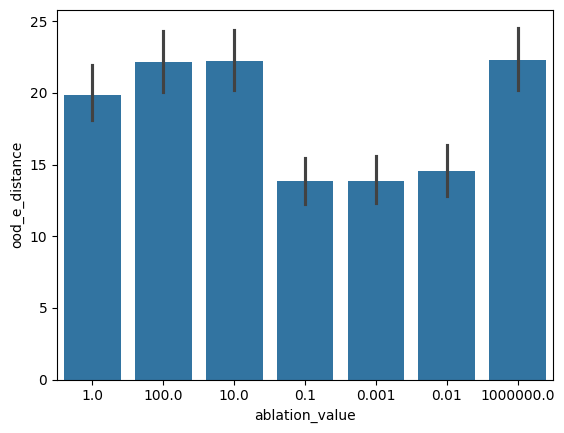

In [15]:
sns.barplot(df, x="ablation_value", y="ood_e_distance")

<Axes: xlabel='ablation_value', ylabel='mean_decoded_r_sq_per_cell_type'>

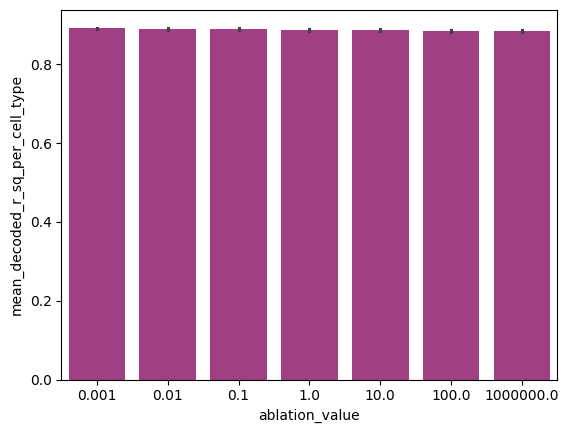

In [18]:
df["ablation_value"] = df["ablation_value"].astype("float")
sns.barplot(df, x="ablation_value", y="mean_decoded_r_sq_per_cell_type", color="#B12F8C")

In [19]:
df.groupby("ablation_value").count()

,mean_decoded_r_sq_per_cell_type,mean_e_distance_per_cell_type,mean_deg_r_sq_per_cell_type,decoded_r_squared_CD8 Naive,decoded_r_squared_B Naive,decoded_r_squared_CD14 Mono,decoded_r_squared_CD4 Naive,decoded_r_squared_CD56-dim NK,decoded_r_squared_CD4 Memory,decoded_r_squared_cDC,...,deg_decoded_r_squared_B Intermediate/Memory,deg_decoded_r_squared_NKT,deg_decoded_r_squared_CD16 Mono,decoded_ood_r_squared,ood_e_distance,wandb_name,cytokine_in_train,decoded_r_squared_pDC,e_distance_pDC,deg_decoded_r_squared_pDC
ablation_value,,,,,,,,,,,,,,,,,,,,,
0.001,230,230,230,230,230,230,230,230,230,230,...,230,207,230,230,230,230,230,207,207,207
0.010,220,220,220,220,220,220,220,220,220,220,...,220,198,220,220,220,220,220,198,198,198
0.100,230,230,230,230,230,230,230,230,230,230,...,230,207,230,230,230,230,230,207,207,207
1.000,230,230,230,230,230,230,230,230,230,230,...,230,207,230,230,230,230,230,207,207,207
10.000,220,220,220,220,220,220,220,220,220,220,...,220,198,220,220,220,220,220,198,198,198
100.000,230,230,230,230,230,230,230,230,230,230,...,230,207,230,230,230,230,230,207,207,207
1000000.000,210,210,210,210,210,210,210,210,210,210,...,210,189,210,210,210,210,210,189,189,189


In [23]:
pd

,mean_decoded_r_sq_per_cell_type,mean_e_distance_per_cell_type,mean_deg_r_sq_per_cell_type,decoded_r_squared_CD8 Naive,decoded_r_squared_B Naive,decoded_r_squared_CD14 Mono,decoded_r_squared_CD4 Naive,decoded_r_squared_CD56-dim NK,decoded_r_squared_CD4 Memory,decoded_r_squared_cDC,...,deg_decoded_r_squared_NKT,deg_decoded_r_squared_CD16 Mono,decoded_ood_r_squared,ood_e_distance,wandb_name,cytokine_in_train,ablation_value,decoded_r_squared_pDC,e_distance_pDC,deg_decoded_r_squared_pDC
Donor1_IL-32-beta,0.896239,51.75219079034171,0.6832390810762133,0.8565002083778381,0.9668196439743042,0.9355778098106384,0.9622517824172974,0.9391927719116211,0.968292236328125,0.8944056034088135,...,0.8131109476089478,-0.24605798721313477,0.9676733016967773,8.765045,fine-pond-70,81,1.0,NaN,NaN,NaN
Donor1_M-CSF,0.857967,62.218344174900125,0.5233728090922037,0.9042059183120728,0.9000828266143799,0.8952832221984863,0.9429531693458557,0.9502314329147339,0.9175569415092468,0.9364036917686462,...,0.5059521198272705,0.5359184741973877,0.9415334463119507,28.419746,warm-sun-144,33,100.0,0.5793813467025757,13.8426743492669,-0.06571316719055176
Donor1_BAFF,0.893622,38.0475559399598,0.6482022364934286,0.9137613773345947,0.9408348798751831,0.9774750471115112,0.9728409051895142,0.9661602973937988,0.9637236595153809,0.9575556516647339,...,0.8181686401367188,0.8980046510696411,0.977477490901947,6.448867,different-glitter-151,5,10.0,0.5321063995361328,13.841626039571167,-0.6553794145584106
Donor1_CD27L,0.899233,31.36517229819919,0.7239750226338705,0.9342504143714905,0.9358732104301453,0.9759329557418823,0.9705104827880859,0.9630130529403687,0.9621297717094421,0.954566240310669,...,0.7913720607757568,0.682522177696228,0.9707953333854675,10.661702,smart-frog-10,2,10.0,0.5129772424697876,11.977604400208577,-0.41205382347106934
Donor1_IL-1Ra,0.885040,29.35762333049629,0.6741024136543274,0.914777398109436,0.9495187401771545,0.9750688076019287,0.9740812182426453,0.9601049423217773,0.9631273150444031,0.9341113567352295,...,0.7200176119804382,0.8000626564025879,0.9807448387145996,1.823352,still-pyramid-12,2,0.1,0.48236387968063354,13.277926827881373,-0.505298376083374


In [21]:
df.drop_duplicates("mean_decoded_r_sq_per_cell_type").shape

(1570, 53)

In [46]:
df["cytokine_in_train"] = df["cytokine_in_train"].astype("float")
df.groupby("ablation_value")["cytokine_in_train"].mean()

ablation_value
1024    31.333333
128     28.066667
16      30.722222
2048    24.466667
256     24.933333
32      27.311377
4096    19.142857
512     25.153846
64      31.777778
Name: cytokine_in_train, dtype: float64

In [48]:
df.columns

Index(['mean_decoded_r_sq_per_cell_type', 'mean_e_distance_per_cell_type',
       'mean_deg_r_sq_per_cell_type', 'decoded_r_squared_CD8 Naive',
       'decoded_r_squared_B Naive', 'decoded_r_squared_B Intermediate/Memory',
       'decoded_r_squared_CD14 Mono', 'decoded_r_squared_CD4 Naive',
       'decoded_r_squared_CD56-dim NK', 'decoded_r_squared_CD4 Memory',
       'decoded_r_squared_cDC', 'decoded_r_squared_CD8 Memory',
       'decoded_r_squared_CD16 Mono', 'decoded_r_squared_CD56-bright NK',
       'decoded_r_squared_MAIT', 'decoded_r_squared_Treg',
       'decoded_r_squared_NKT', 'decoded_r_squared_pDC',
       'e_distance_CD8 Naive', 'e_distance_B Naive',
       'e_distance_B Intermediate/Memory', 'e_distance_CD14 Mono',
       'e_distance_CD4 Naive', 'e_distance_CD56-dim NK',
       'e_distance_CD4 Memory', 'e_distance_cDC', 'e_distance_CD8 Memory',
       'e_distance_CD16 Mono', 'e_distance_CD56-bright NK', 'e_distance_MAIT',
       'e_distance_Treg', 'e_distance_NKT', 'e_dist

In [49]:
df.shape

(1367, 53)